# DS4: Kalman filter and smoother (practice)

## Pierre Tandeo, IMT-Atlantique (pierre.tandeo@imt-atlantique.fr)

We consider an object moving in the 2D plane. Its real trajectory (blue curve) is assumed to be unknown. We only have noisy observations (black dots) of its position. The objective of this practical work is to find the real trajectory from the observations via a filter and a Kalman smoother. To better constrain the estimation of positions over time, we introduce the speed information into the state vector.

The dynamics used here is given by: $x_1(t) = x_1(t-dt) + dt \dot{x}_1(t-dt)$ and $x_2(t) = x_2(t-dt) + dt \dot{x}_2(t-dt) $, with dt=1 and $t$ varying from $1$ to $200$ in our case.

**1)** We generate the hidden state ${\bf x}$ as well as the partial and noisy observations ${\bf y}$:

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


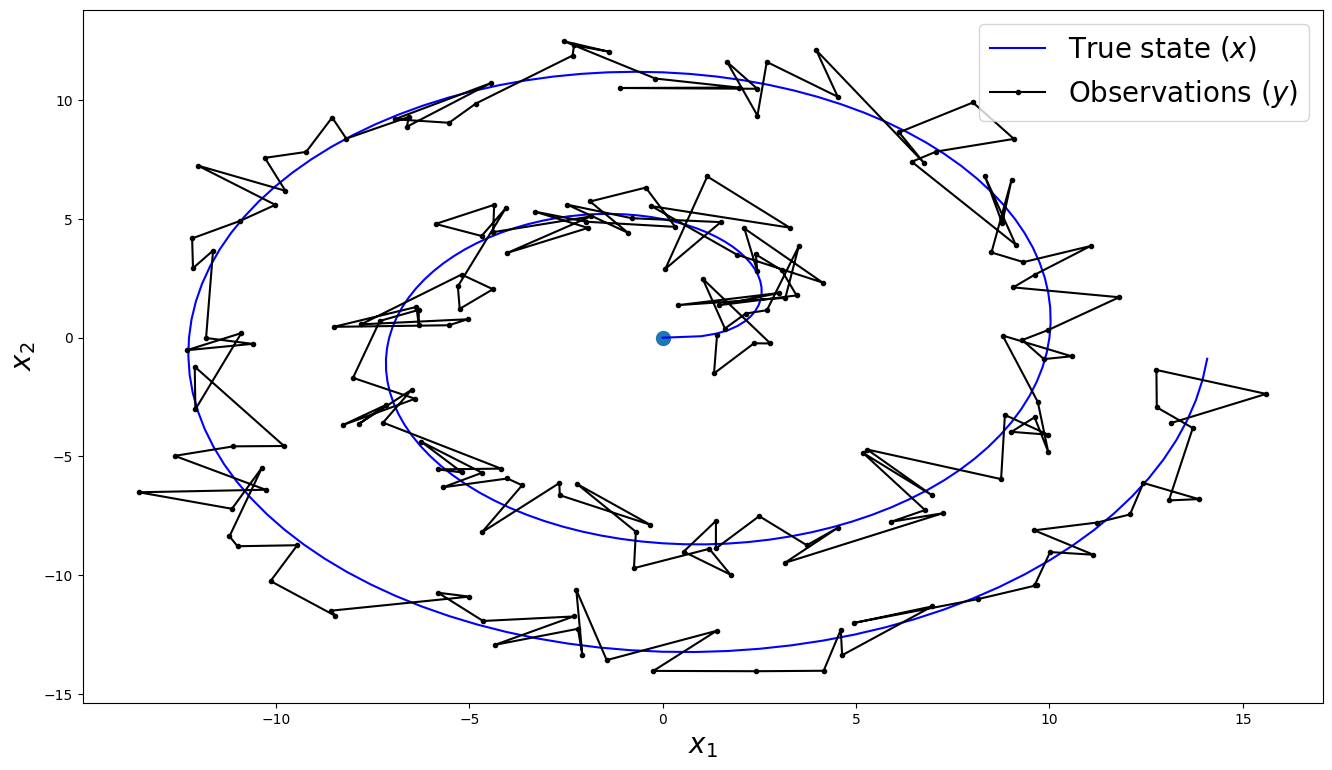

In [1]:
%pylab inline
pylab.rcParams['figure.figsize'] = (16.0, 9.0)

### parameters
n     = 4 # state size
p     = 2 # observation size
nb    = 200 # number of times
time  = array(range(nb)) # time vector
var_Q = 0.1 # error variance of the model (in Kalman)
var_R = 1 # error variance of the observations (in Kalman)
x_0   = zeros((n)) # initial coundition (mean)
P_0   = eye(n,n) # initial coundition (covariance)

### variables
Q      = var_Q*eye(n,n)
R      = var_R*eye(p,p)
x1     = sqrt(time)*cos(2*pi*time/(nb/2)) # true x1 position
x2     = sqrt(time)*sin(2*pi*time/(nb/2)) # true x2 position
x1_dot = x1[time[1:-1]]-x1[time[0:-2]] # true x1 speed
x2_dot = x2[time[1:-1]]-x2[time[0:-2]] # true x2 speed
x1_dot = r_[x1_dot[0], x1_dot, x1_dot[-1]]
x2_dot = r_[x2_dot[0], x2_dot, x2_dot[-1]]

### true state and noisy observations
x = c_[x1, x2, x1_dot, x2_dot].T # true state
y = c_[x1, x2].T + randn(p,nb) # noisy observations

### plot trajectories (true, observed)
plot(x[0,:], x[1,:], 'b', label='True state ($x$)')
plot(y[0,:], y[1,:], '.-k', label='Observations ($y$)')
scatter(x[0,0], x[1,0], 100)
xlabel('$x_1$', fontsize=20)
ylabel('$x_2$', fontsize=20)
legend(fontsize=20)

**2)** What do the components of the state vector and the observation vector represent? Complete the operators $M$ and $H$ of the space-state model:

In [2]:
### linear operators of the state-space model
M = array([[1,0,1,0], [0,1,0,1], [0,0,1,0], [0,0,0,1]]) ### A CACHER
H = array([[1,0,0,0], [0,1,0,0]]) ### A CACHER

### Kalman initialization
x_f = zeros((n,nb))   # forecast state
P_f = zeros((n,n,nb)) # forecast error covariance matrix
x_a = zeros((n,nb))   # analysed state
P_a = zeros((n,n,nb)) # analysed error covariance matrix
x_s = zeros((n,nb))   # smoothed state
P_s = zeros((n,n,nb)) # smoothed error covariance matrix

**3)** Complete the Kalman filter (prediction step, gain $K$, update step) knowing that the formulas are:
\begin{align*}
    x^f(t) &= M x^a(t-1) \\
    P^f(t) &= M P^a(t-1) M^{T}+Q \\
    K &= P^f(t) H^{T} \left(H P^f(t) H^{T} + R\right)^{-1} \\
    x^a(t) &= x^f(t) + K \left(y(t) - H x^f(t)\right) \\
    P^a(t) &= P^f(t) -K H P^f(t) \\
\end{align*}

In [3]:
### Kalman filter
x_a[:,0]   = x_0 # initial state
P_a[:,:,0] = P_0 # initial state covariance
for k in range(1,nb): # forward in time
    # prediction step
    x_f[:,k] = M @ x_a[:,k-1] ### A CACHER
    P_f[:,:,k] = M @ P_a[:,:,k-1] @ M.T + Q ### A CACHER
    # Kalman gain
    K = P_f[:,:,k] @ H.T @ inv(H @ P_f[:,:,k] @ H.T + R) ### A CACHER
    # update step
    x_a[:,k] = x_f[:,k] + K @ (y[:,k] - H @ x_f[:,k]) ### A CACHER
    P_a[:,:,k] = P_f[:,:,k] - K @ H @ P_f[:,:,k] ### A CACHER

**4)** Complete the Kalman smoother knowing that the formulas are:
\begin{align*}
    K &= P^a(t) M^{T} P^f(t+1)^{-1} \\
	x^s(t) &= x^a(t) + K \left(x^s(t+1) - x^f(t+1)\right) \\
	P^s(t) &= P^a(t) + K \left(P^s(t+1) - P^f(t+1)\right) K^{T} \\
\end{align*}

In [4]:
### Kalman smoother
x_s[:,-1]  = x_a[:,-1] # initial state
P_s[:,:,-1]= P_a[:,:,-1] # initial state covariance
for k in range(nb-2,-1,-1): # backward in time
    K = P_a[:,:,k] @ M.T @ inv(P_f[:,:,k+1]) ### A CACHER
    x_s[:,k] = x_a[:,k] + K @ (x_s[:,k+1] - x_f[:,k+1]) ### A CACHER
    P_s[:,:,k] = P_a[:,:,k] + K @ (P_s[:,:,k+1] - P_f[:,:,k+1]) @ K.T ### A CACHER

**5)** Compare the results of Kalman filtering and smoothing:

RMSE(obs): 1.0109989414190816
RMSE(filter): 0.6876505286546333
RMSE(smoother): 0.39536881904329213


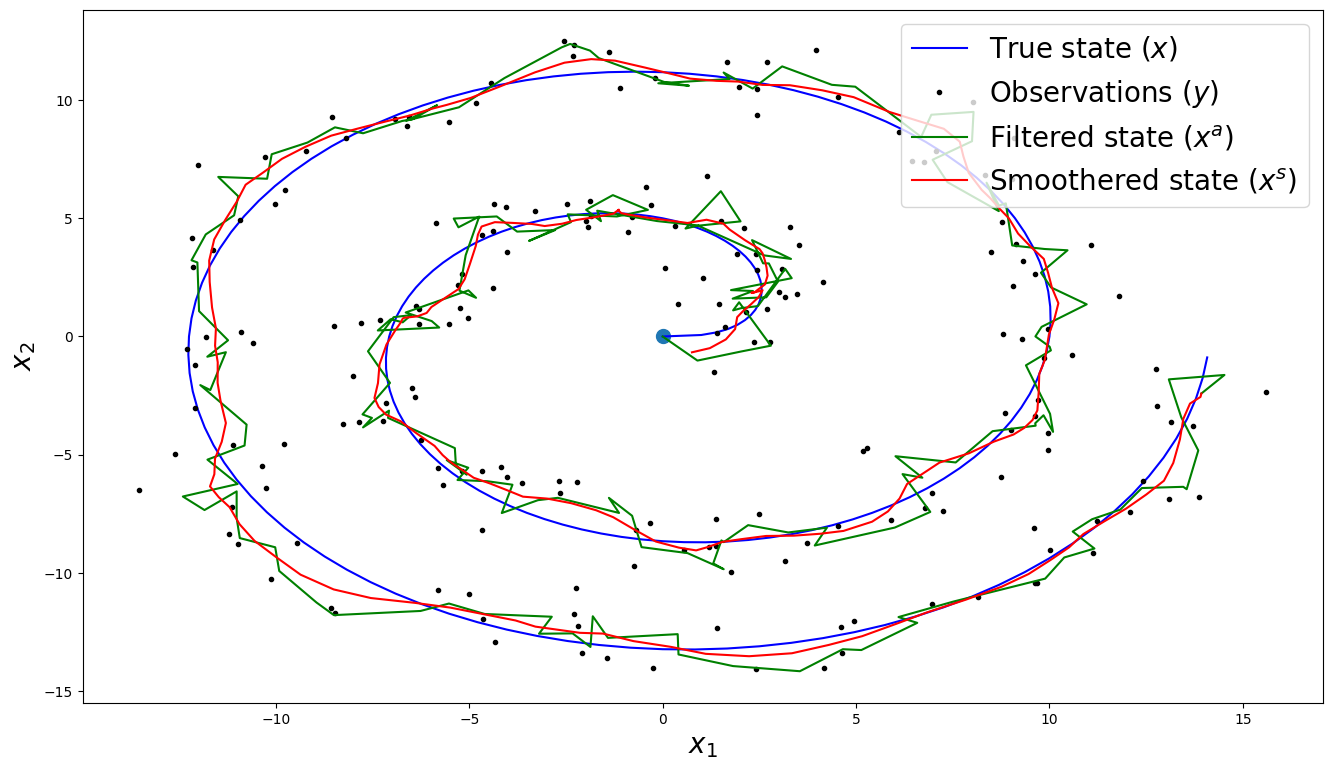

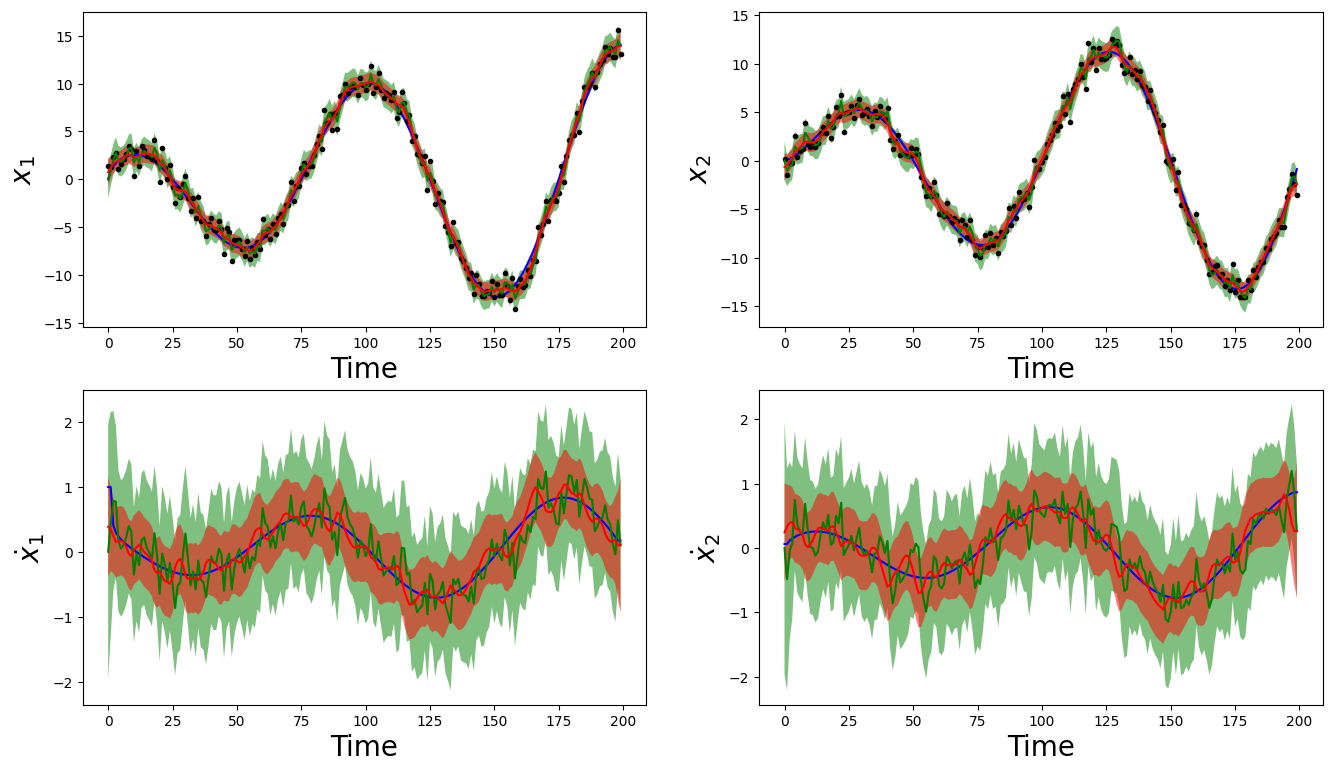

In [5]:
### plot trajectories (true, observed, filtered, smoothered)
plot(x[0,:], x[1,:], 'b', label='True state ($x$)')
plot(y[0,:], y[1,:], '.k', label='Observations ($y$)')
plot(x_a[0,:], x_a[1,:], 'g', label='Filtered state ($x^a$)')
plot(x_s[0,:], x_s[1,:], 'r', label='Smoothered state ($x^s$)')
scatter(x[0,0], x[1,0], 100)
xlabel('$x_1$', fontsize=20)
ylabel('$x_2$', fontsize=20)
legend(fontsize=20)

### plot state variables
figure()
y_label=('$x_1$', '$x_2$', '$\dot{x}_1$', '$\dot{x}_2$')
for i in range(4):
    subplot(2,2,i+1)
    plot(time, x[i,:], 'b')
    if ((i==0) or (i==1)):
        plot(time, y[i,:], '.k')
    plot(time, x_a[i,:], 'g')
    fill_between(time, x_a[i,:] - 1.96*sqrt(P_a[i,i,:]), x_a[i,:] + 1.96*sqrt(P_a[i,i,:]), facecolor='green', alpha=0.5)
    plot(time, x_s[i,:], 'r')
    fill_between(time, x_s[i,:] - 1.96*sqrt(P_s[i,i,:]), x_s[i,:] + 1.96*sqrt(P_s[i,i,:]), facecolor='red', alpha=0.5)
    xlabel('Time', size=20)
    ylabel(y_label[i], size=20)
    
### compute Root Mean Squared Errors (RMSE) of the positions
print('RMSE(obs):', sqrt(mean((y[range(2),:] - x[range(2),:])**2))) ### A CACHER
print('RMSE(filter):', sqrt(mean((x_a[range(2),:] - x[range(2),:])**2))) ### A CACHER
print('RMSE(smoother):', sqrt(mean((x_s[range(2),:] - x[range(2),:])**2))) ### A CACHER

**6)** Test the influence of the initial condition (i.e., $x_0$ and $P_0$), as well as the model and observation covariances (i.e., $ Q $ and $ R $) on the quality of the filtering and smoothing results.

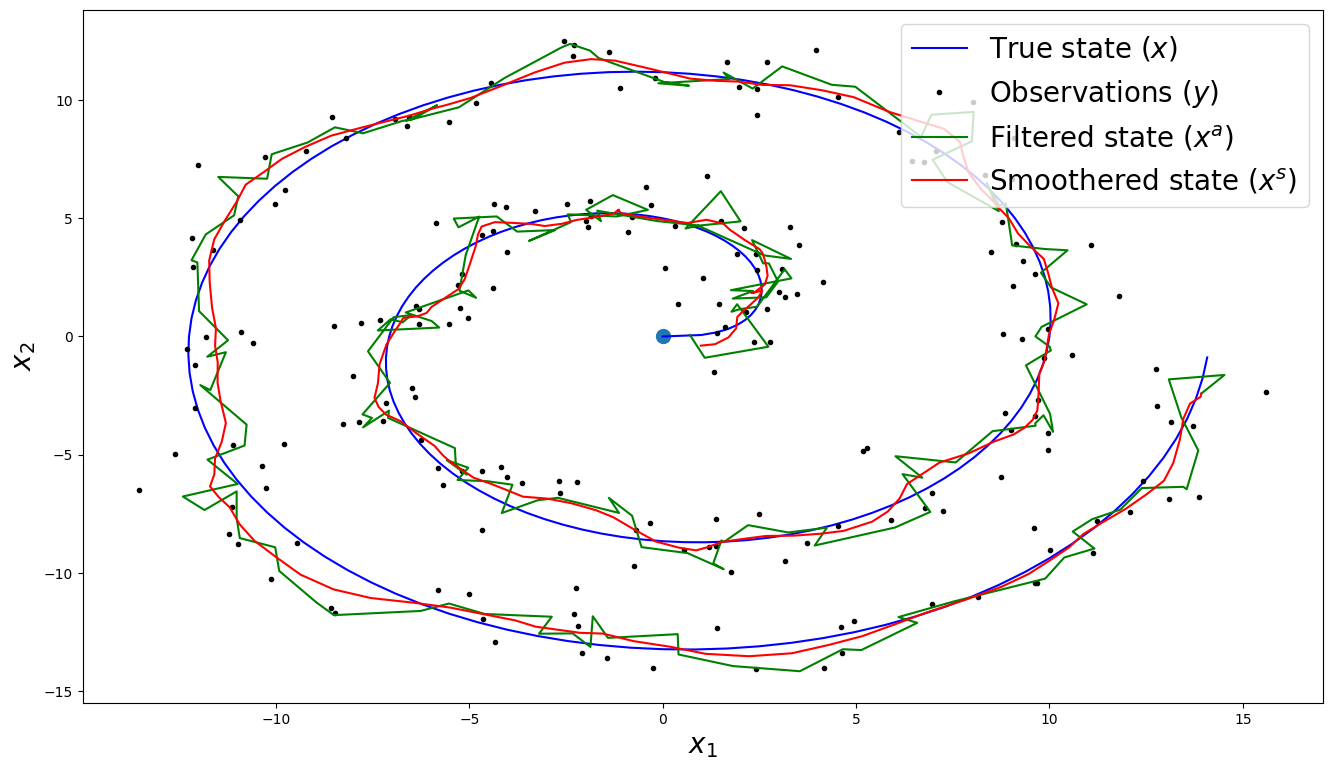

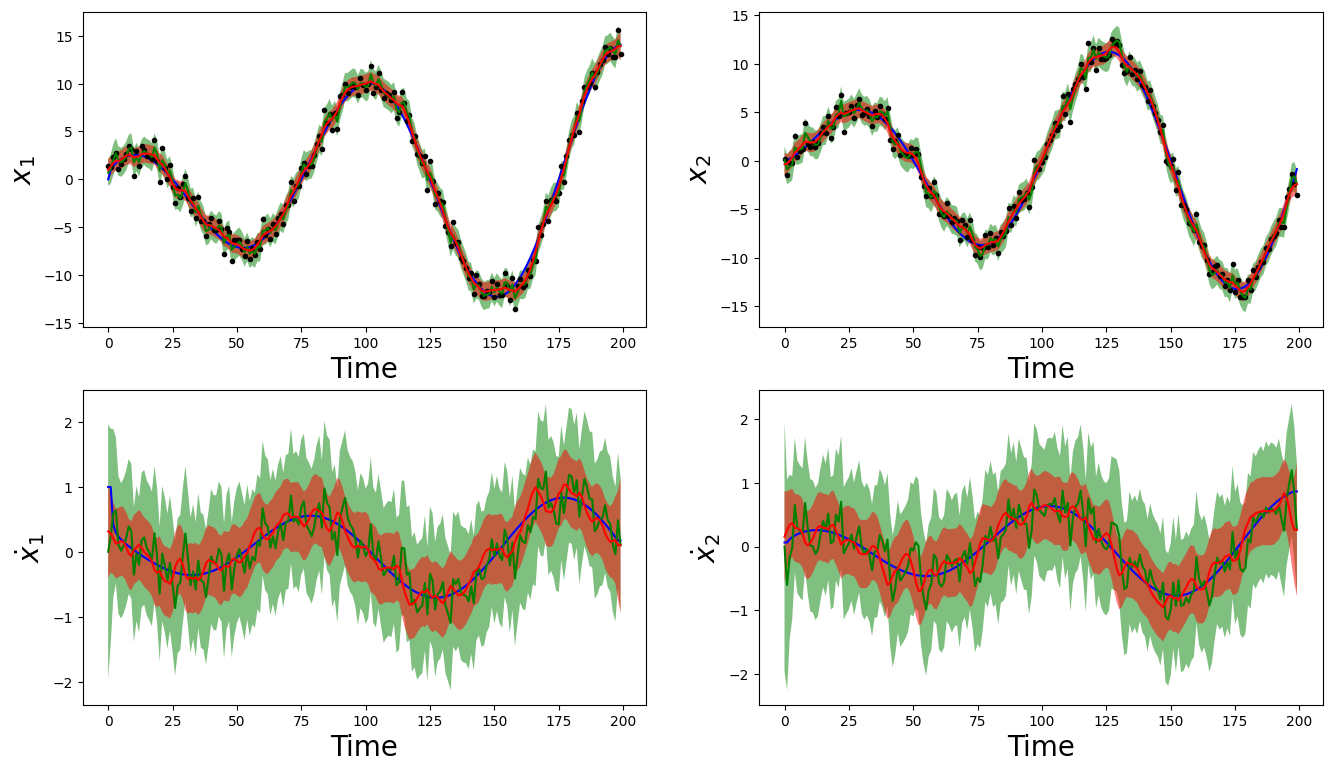

In [ ]:
### import pykalman
from pykalman import KalmanFilter

import warnings
warnings.filterwarnings("ignore")

### change the Kalman parameters
# no modification
x_0   = zeros((n)) # initial coundition (mean)
P_0   = eye(n,n) # initial coundition (covariance)
Q     = 0.1*eye(n,n)
R     = 1*eye(p,p)
'''
# x0 modified
x_0   = 20 + zeros((n)) # initial coundition (mean)
P_0   = eye(n,n) # initial coundition (covariance)
Q     = 0.1*eye(n,n) 
R     = 1*eye(p,p)
# x0 and P0 modified
x_0   = 20 + zeros((n)) # initial coundition (mean)
P_0   = 0.01 * eye(n,n) # initial coundition (covariance)
Q     = 0.1*eye(n,n) 
R     = 1*eye(p,p)
# Q modified
x_0   = zeros((n)) # initial coundition (mean)
P_0   = eye(n,n) # initial coundition (covariance)
Q     = 0.0001*eye(n,n) 
R     = 1*eye(p,p)
# R modified
x_0   = zeros((n)) # initial coundition (mean)
P_0   = eye(n,n) # initial coundition (covariance)
Q     = 0.1*eye(n,n) 
R     = 0.0001*eye(p,p)
'''

### declare the state-space model
ssm_position = KalmanFilter(transition_matrices = M, observation_matrices = H,
                            initial_state_mean = x_0, initial_state_covariance = P_0,
                            transition_covariance = Q, observation_covariance = R)

### apply Kalman filter and smoother
x_a, P_a = ssm_position.filter(y.T)
x_s, P_s = ssm_position.smooth(y.T)

### reshape outputs
x_a = x_a.T
x_s = x_s.T
P_a = swapaxes(P_a, 0, 2)
P_s = swapaxes(P_s, 0, 2)

### plot trajectories (true, observed, filtered, smoothered)
plot(x[0,:], x[1,:], 'b', label='True state ($x$)')
plot(y[0,:], y[1,:], '.k', label='Observations ($y$)')
plot(x_a[0,:], x_a[1,:], 'g', label='Filtered state ($x^a$)')
plot(x_s[0,:], x_s[1,:], 'r', label='Smoothered state ($x^s$)')
scatter(x[0,0], x[1,0], 100)
xlabel('$x_1$', fontsize=20)
ylabel('$x_2$', fontsize=20)
legend(fontsize=20)

### plot state variables
figure()
y_label=('$x_1$', '$x_2$', '$\dot{x}_1$', '$\dot{x}_2$')
for i in range(4):
    subplot(2,2,i+1)
    plot(time, x[i,:], 'b')
    if ((i==0) or (i==1)):
        plot(time, y[i,:], '.k')
    plot(time, x_a[i,:], 'g')
    fill_between(time, x_a[i,:] - 1.96*sqrt(P_a[i,i,:]), x_a[i,:] + 1.96*sqrt(P_a[i,i,:]), facecolor='green', alpha=0.5)
    plot(time, x_s[i,:], 'r')
    fill_between(time, x_s[i,:] - 1.96*sqrt(P_s[i,i,:]), x_s[i,:] + 1.96*sqrt(P_s[i,i,:]), facecolor='red', alpha=0.5)
    xlabel('Time', size=20)
    ylabel(y_label[i], size=20)

Automatic estimation of $x_0$, $P_0$, $Q$, and $R$ using expectation-maximization (EM) algorithm:

Estimated x0:
[ 1.44 -0.61  0.17  0.27]
Estimated P_0:
[[ 0.05 -0.   -0.01  0.  ]
 [-0.    0.05  0.   -0.01]
 [-0.01  0.    0.01 -0.  ]
 [ 0.   -0.01 -0.    0.01]]
Estimated R:
[[ 0.99 -0.02]
 [-0.02  0.88]]
Estimated Q:
[[ 0.08 -0.    0.    0.  ]
 [-0.    0.09 -0.    0.  ]
 [ 0.   -0.    0.03 -0.  ]
 [ 0.    0.   -0.    0.03]]


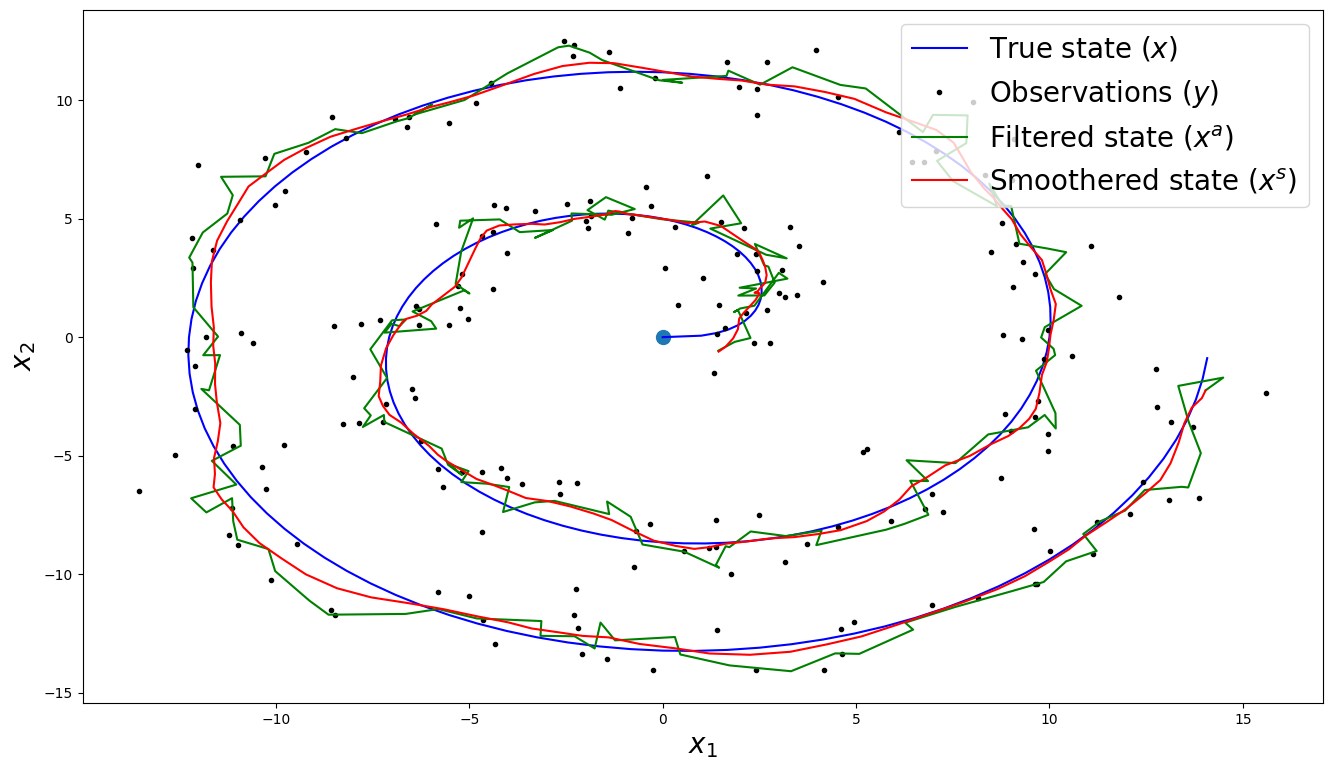

In [25]:
### declare the state-space model
ssm_position_optimized = KalmanFilter(transition_matrices = M, observation_matrices = H,
                                      initial_state_mean = x_0, initial_state_covariance = P_0,
                                      transition_covariance = Q, observation_covariance = R,
                                      em_vars=['initial_state_mean', 'initial_state_covariance', 'transition_covariance', 'observation_covariance'])

### apply EM algorithm to tune Q and R
param = ssm_position_optimized.em(y.T, n_iter=10)

### print the estimated parameters
print('Estimated x0:')
print(str(around(param.initial_state_mean, 2)))
print('Estimated P_0:')
print(str(around(param.initial_state_covariance, 2)))
print('Estimated R:')
print(str(around(param.observation_covariance, 2)))
print('Estimated Q:')
print(str(around(param.transition_covariance, 2)))

### apply Kalman filter and smoother with the optimized parameters
x_a, P_a = ssm_position_optimized.filter(y.T)
x_s, P_s = ssm_position_optimized.smooth(y.T)

### reshape outputs
x_a = x_a.T
x_s = x_s.T
P_a = swapaxes(P_a, 0, 2)
P_s = swapaxes(P_s, 0, 2)

### plot trajectories (true, observed, filtered, smoothered)
plot(x[0,:], x[1,:], 'b', label='True state ($x$)')
plot(y[0,:], y[1,:], '.k', label='Observations ($y$)')
plot(x_a[0,:], x_a[1,:], 'g', label='Filtered state ($x^a$)')
plot(x_s[0,:], x_s[1,:], 'r', label='Smoothered state ($x^s$)')
scatter(x[0,0], x[1,0], 100)
xlabel('$x_1$', fontsize=20)
ylabel('$x_2$', fontsize=20)
legend(fontsize=20)